# EDA 04 - Darwin Timetable

**Data source**: `darwin-timetable-feeds` Azure container - XML timetable files  
**Loaded by**: `src/data_loader.load_darwin_timetable()`  
**Output**: `data/processed/darwin_timetable_clean.parquet`

The Darwin timetable provides the scheduled service plan for the observation period. Unlike train moments (which record what actually happened), the timetable records what was planned. It is used in the main notebook to generate forward-looking delay predictions for scheduled services. This EDA examines the structure, coverage, and quality of the timetable data independently before it enters the join pipeline.

---
**Sections**
1. Load and inspect  
2. Missing value audit  
3. TOC (train operating company) distribution  
4. Stop type distribution  
5. Service date coverage  
6. Planned time field coverage (wta / wtd / wtp)  
7. Service frequency by hour  
8. Journey-level statistics (stops per journey)  
9. TIPLOC match rate  
10. Save cleaned output  


## 0. Setup

In [22]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_04", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect

In [23]:
from datetime import datetime, timezone
from src.data_loader import load_darwin_timetable

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

timetable_df = load_darwin_timetable(START, END)
print(f"Shape: {timetable_df.shape}")
print(f"Columns: {list(timetable_df.columns)}")
print(f"Unique journeys (rid): {timetable_df['rid'].nunique():,}")
timetable_df.head(3)

Total: 69.08538675308228
Shape: (18215990, 14)
Columns: ['rid', 'uid', 'trainId', 'ssd', 'toc', 'stop_type', 'tpl', 'platform', 'act', 'pta', 'ptd', 'wta', 'wtd', 'wtp']
Unique journeys (rid): 633,103


,rid,uid,trainId,ssd,toc,stop_type,tpl,platform,act,pta,ptd,wta,wtd,wtp
0,202604108062281,P62281,2S69,2026-04-10,SW,OR,WATRLMN,18,TB,NaN,21:22,NaN,21:22,NaN
1,202604108062281,P62281,2S69,2026-04-10,SW,PP,WATRLWC,NaN,NaN,NaN,NaN,NaN,NaN,21:23:30
2,202604108062281,P62281,2S69,2026-04-10,SW,IP,VAUXHLM,NaN,T,21:26,21:26,21:25:30,21:26:30,NaN


## Data Types and Basic Statistics

In [24]:
timetable_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18215990 entries, 0 to 18215989
Data columns (total 14 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   rid        str   
 1   uid        str   
 2   trainId    str   
 3   ssd        object
 4   toc        str   
 5   stop_type  str   
 6   tpl        str   
 7   platform   str   
 8   act        str   
 9   pta        str   
 10  ptd        str   
 11  wta        str   
 12  wtd        str   
 13  wtp        str   
dtypes: object(1), str(13)
memory usage: 2.8+ GB


In [25]:
timetable_df.describe().round(2)

,rid,uid,trainId,ssd,toc,stop_type,tpl,platform,act,pta,ptd,wta,wtd,wtp
count,18215990,18215990,18215990,18215990,18215990,18215990,18215122,9892406,10913389,9140346,9128802,9726897,9726830,7329932
unique,633103,107074,9658,22,42,8,5160,233,232,1440,1439,2886,2877,3314
top,202604207611879,C75334,0B00,2026-04-23,NT,IP,LNDNBDE,1,T,18:09,18:00,00:01,18:00,16:36
freq,379,3905,409381,1099409,1825432,8262436,48768,3551390,8061867,11013,11136,6997,7400,4495


## 2. Missing Value Audit

In [26]:
missing = pd.DataFrame({
    "missing_count": timetable_df.isna().sum(),
    "missing_pct":   (timetable_df.isna().sum() / len(timetable_df) * 100).round(2),
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

# Time fields are the most critical — low coverage means fewer rows
# usable for scheduled time derivation
print()
for col in ["wta", "wtd", "wtp", "pta", "ptd"]:
    if col in timetable_df.columns:
        n = timetable_df[col].notna().sum()
        print(f"{col}: {n:,} non-null ({n/len(timetable_df)*100:.1f}%)")

           missing_count  missing_pct
wtp             10886058        59.76
ptd              9087188        49.89
pta              9075644        49.82
wta              8489093        46.60
wtd              8489160        46.60
platform         8323584        45.69
act              7302601        40.09
toc                    0         0.00
stop_type              0         0.00
trainId                0         0.00
uid                    0         0.00
rid                    0         0.00
ssd                    0         0.00
tpl                  868         0.00

wta: 9,726,897 non-null (53.4%)
wtd: 9,726,830 non-null (53.4%)
wtp: 7,329,932 non-null (40.2%)
pta: 9,140,346 non-null (50.2%)
ptd: 9,128,802 non-null (50.1%)


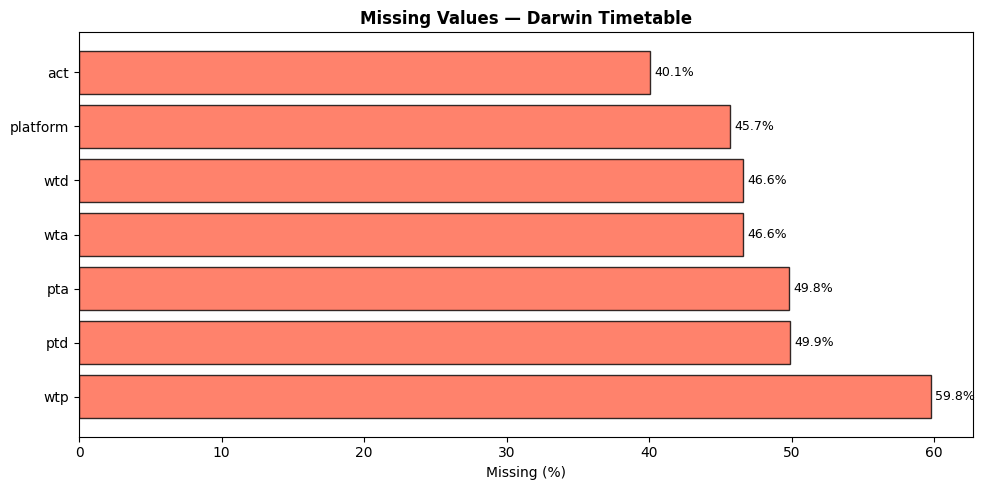

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_nz = missing[missing["missing_pct"] > 0]
if len(missing_nz):
    ax.barh(missing_nz.index, missing_nz["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    for i, v in enumerate(missing_nz["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
ax.set_title("Missing Values — Darwin Timetable", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_04/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

Time field coverage:
     non_null  pct_present
wta   9726897        53.40
wtd   9726830        53.40
wtp   7329932        40.24
pta   9140346        50.18
ptd   9128802        50.11


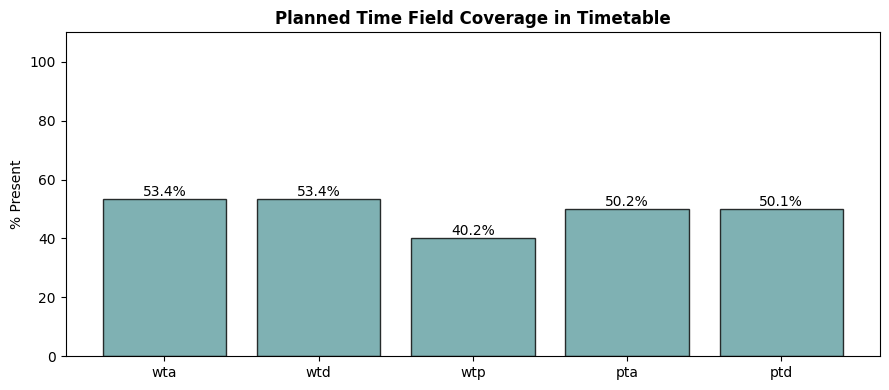

In [28]:
# wta = working time arrival, wtd = working time departure (operational precision)
# pta = public time arrival, ptd = public time departure (passenger-facing, rounded)
# wtp = working time pass (non-stopping locations)
# Coverage determines which stop rows have usable scheduled timestamps

time_cols = [c for c in ["wta", "wtd", "wtp", "pta", "ptd"]
             if c in timetable_df.columns]

coverage = pd.DataFrame({
    "non_null":    [timetable_df[c].notna().sum() for c in time_cols],
    "pct_present": [timetable_df[c].notna().mean() * 100 for c in time_cols],
}, index=time_cols).round(2)

print("Time field coverage:")
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage.index, coverage["pct_present"],
       color="cadetblue", edgecolor="black", alpha=0.8)
ax.set_ylabel("% Present")
ax.set_title("Planned Time Field Coverage in Timetable", fontweight="bold")
ax.set_ylim(0, 110)
for i, v in enumerate(coverage["pct_present"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/eda_04/time_field_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Stop Type Distribution

In [29]:
STOP_TYPE_MAP = {
    "OR":   "Origin",
    "OPOR": "Origin (optional)",
    "IP":   "Intermediate stop",
    "OPIP": "Intermediate (optional pass)",
    "PP":   "Passing point",
    "DT":   "Destination",
    "OPDT": "Destination (optional)",
}

if "stop_type" in timetable_df.columns:
    st_counts = timetable_df["stop_type"].value_counts()
    print("Stop type distribution:")
    for k, v in st_counts.items():
        label = STOP_TYPE_MAP.get(k, k)
        print(f"  {k:6s} ({label:35s}): {v:,} ({v/len(timetable_df)*100:.1f}%)")

Stop type distribution:
  IP     (Intermediate stop                  ): 8,262,436 (45.4%)
  PP     (Passing point                      ): 7,329,932 (40.2%)
  DT     (Destination                        ): 895,005 (4.9%)
  OR     (Origin                             ): 894,993 (4.9%)
  OPIP   (Intermediate (optional pass)       ): 306,101 (1.7%)
  OPDT   (Destination (optional)             ): 263,355 (1.4%)
  OPOR   (Origin (optional)                  ): 263,300 (1.4%)
  cancelReason (cancelReason                       ): 868 (0.0%)


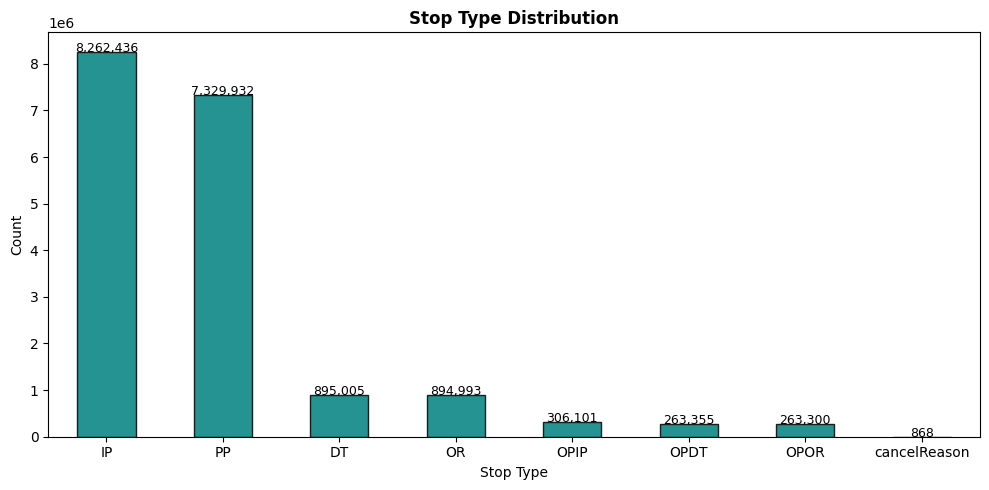

In [30]:
if "stop_type" in timetable_df.columns:
    plt.figure(figsize=(10, 5))
    st_counts.plot(kind="bar", color="teal", edgecolor="black", alpha=0.85)
    plt.xlabel("Stop Type")
    plt.ylabel("Count")
    plt.title("Stop Type Distribution", fontweight="bold")
    plt.tick_params(axis="x", rotation=0)
    for i, v in enumerate(st_counts.values):
        plt.text(i, v + 50, f"{v:,}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/stop_type.png", dpi=200, bbox_inches="tight")
    plt.show()

In [31]:
# Drop invalid stop_type rows — 868 rows where stop_type = "cancelReason"
# These are data artefacts from the XML parser, not valid timetable entries
before = len(timetable_df)
timetable_df = timetable_df[timetable_df["stop_type"] != "cancelReason"].copy()
print(f"Dropped {before - len(timetable_df):,} invalid stop_type rows")
print(f"Remaining: {len(timetable_df):,} rows")

Dropped 868 invalid stop_type rows
Remaining: 18,215,122 rows


## 4. TOC (Train Operating Company) Distribution

In [32]:
if "toc" in timetable_df.columns:
    # Journey-level deduplication — one row per rid
    journey_toc = (
        timetable_df
        .drop_duplicates(subset=["rid"])["toc"]
        .value_counts()
    )
    print(f"Unique TOCs: {len(journey_toc)}")
    print()
    print("Journeys per TOC:")
    print(journey_toc.to_string())

Unique TOCs: 42

Journeys per TOC:
toc
SR    71681
NT    65000
GW    50242
SW    47705
SE    44537
SN    42179
LO    34260
LE    32331
AW    29671
LM    29144
TL    24592
XR    23882
LT    20234
EM    14862
ME    14400
TP    11708
GN    11391
VT    10384
CC    10273
XC    10202
CH     9441
GR     8637
TW     3338
HX     3092
SJ     1675
GX     1513
ZZ     1391
ES     1196
IL     1022
GC      628
HT      530
CS      521
LD      440
WR      359
LF      279
LS      181
TY       78
MV       50
NY       34
SO       17
PX        2
YG        1


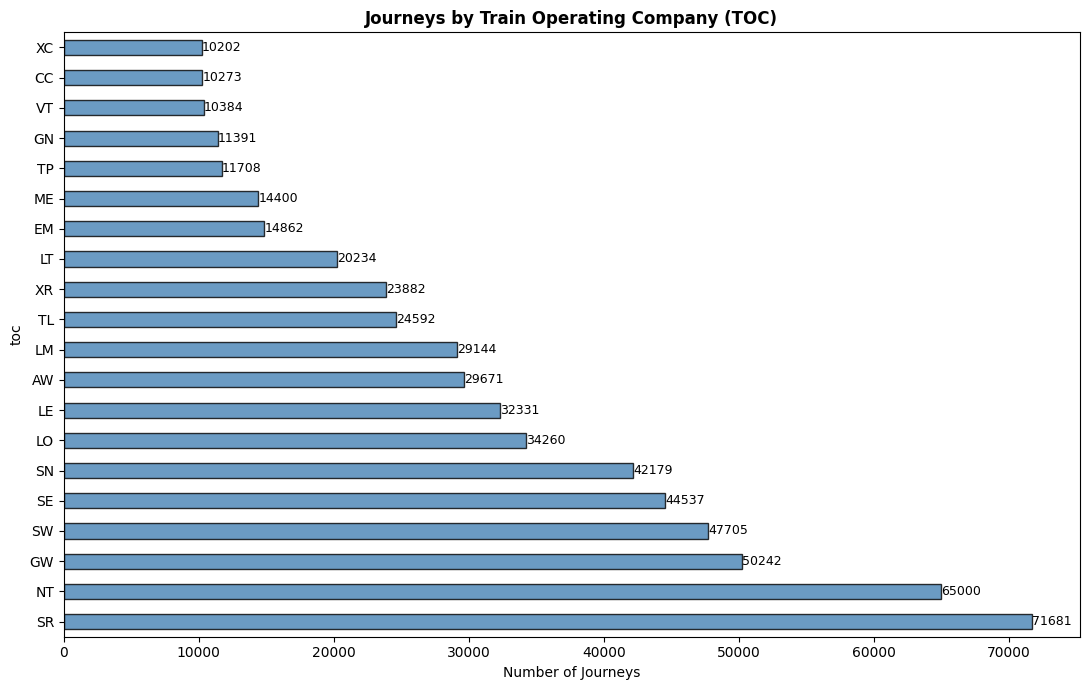

In [33]:
if "toc" in timetable_df.columns:
    journey_toc.head(20).plot(
        kind="barh", color="steelblue", edgecolor="black",
        alpha=0.8, figsize=(11, 7)
    )
    plt.xlabel("Number of Journeys")
    plt.title("Journeys by Train Operating Company (TOC)", fontweight="bold")
    for i, v in enumerate(journey_toc.head(20).values):
        plt.text(v + 2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/toc_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Service Date Coverage

Stop rows by service date:
ssd
2026-04-09       6020
2026-04-10     542691
2026-04-11     492732
2026-04-12     318574
2026-04-13    1079059
2026-04-14    1088780
2026-04-15    1090209
2026-04-16    1091406
2026-04-17    1087989
2026-04-18     952535
2026-04-19     620873
2026-04-20    1092326
2026-04-21    1096782
2026-04-22    1097039
2026-04-23    1099388
2026-04-24    1098288
2026-04-25     980001
2026-04-26     641943
2026-04-27    1092026
2026-04-28    1091438
2026-04-29     549491
2026-04-30       5532

Unique journeys by service date:
ssd
2026-04-09      527
2026-04-10    32930
2026-04-11    31477
2026-04-12    21986
2026-04-13    33324
2026-04-14    33765
2026-04-15    33783
2026-04-16    33775
2026-04-17    33640
2026-04-18    31814
2026-04-19    22761
2026-04-20    33301
2026-04-21    33738
2026-04-22    33717
2026-04-23    33734
2026-04-24    33533
2026-04-25    31874
2026-04-26    21975
2026-04-27    33245
2026-04-28    33664
2026-04-29    33705
2026-04-30      835


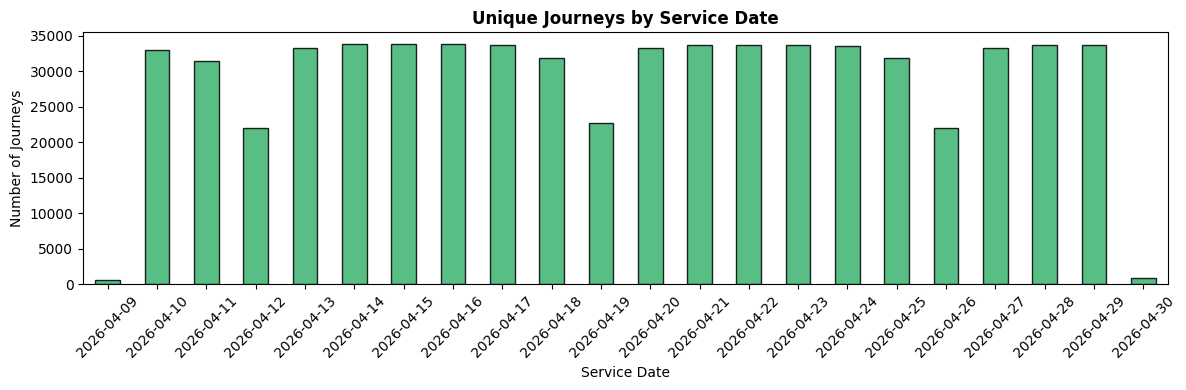

In [34]:
if "ssd" in timetable_df.columns:
    date_counts = timetable_df["ssd"].value_counts().sort_index()
    print("Stop rows by service date:")
    print(date_counts.to_string())
    print()

    journey_dates = (
        timetable_df
        .drop_duplicates(subset=["rid"])["ssd"]
        .value_counts()
        .sort_index()
    )
    print("Unique journeys by service date:")
    print(journey_dates.to_string())

    fig, ax = plt.subplots(figsize=(12, 4))
    journey_dates.plot(kind="bar", ax=ax, color="mediumseagreen",
                       edgecolor="black", alpha=0.85)
    ax.set_xlabel("Service Date")
    ax.set_ylabel("Number of Journeys")
    ax.set_title("Unique Journeys by Service Date", fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig("figures/eda_04/service_date_coverage.png", dpi=200, bbox_inches="tight")
    plt.show()

Scheduled stop rows by hour:
sched_hour
0     151076
1      41500
2      11097
3       7645
4      33954
5     185295
6     450156
7     547196
8     559010
9     546804
10    527872
11    523481
12    520449
13    520481
14    522507
15    534379
16    557176
17    581030
18    576993
19    541785
20    500484
21    474299
22    442138
23    370023


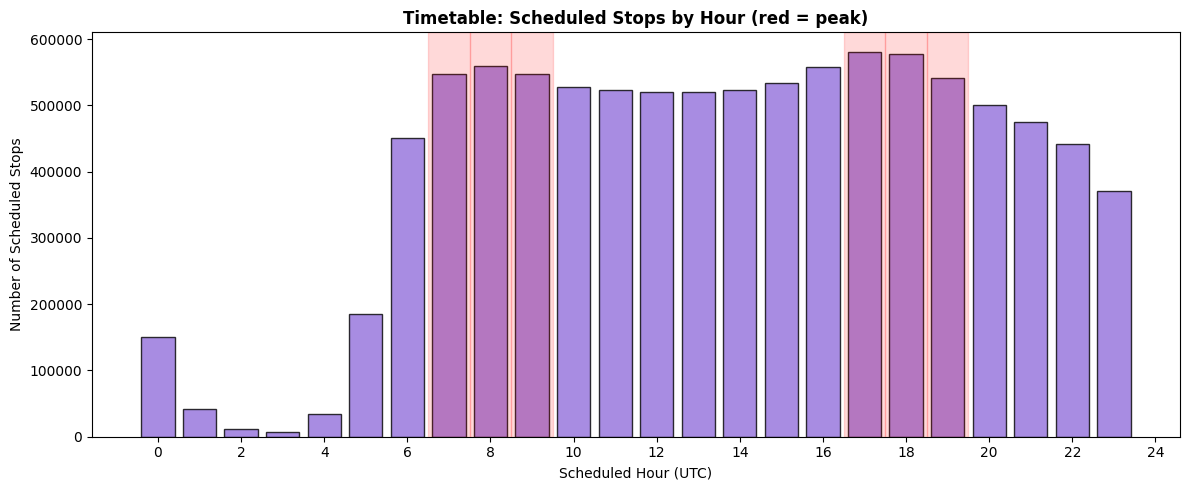

In [35]:
# Mirrors the temporal distribution analysis in eda_03
# Shows when scheduled services are concentrated across the day
# Peak shading consistent with eda_03 definition (07-09, 17-19)

def parse_hhmm(s):
    try:
        parts = str(s).strip().split(":")
        if len(parts) >= 2:
            return int(parts[0])
    except Exception:
        pass
    return None

# Use wtd (working departure) as primary; fall back to wta
time_col = "wtd" if "wtd" in timetable_df.columns else "wta"
timetable_df["sched_hour"] = timetable_df[time_col].apply(parse_hhmm)

hour_counts = (
    timetable_df["sched_hour"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

print("Scheduled stop rows by hour:")
print(hour_counts.to_string())

plt.figure(figsize=(12, 5))
plt.bar(hour_counts.index, hour_counts.values,
        color="mediumpurple", edgecolor="black", alpha=0.8)
for h in list(range(7, 10)) + list(range(17, 20)):
    plt.axvspan(h - 0.5, h + 0.5, alpha=0.15, color="red")
plt.xlabel("Scheduled Hour (UTC)")
plt.ylabel("Number of Scheduled Stops")
plt.title("Timetable: Scheduled Stops by Hour (red = peak)", fontweight="bold")
plt.xticks(range(0, 25, 2))
plt.tight_layout()
plt.savefig("figures/eda_04/service_frequency_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

Stops per journey statistics:
count    633103.0
mean         28.8
std          25.2
min           2.0
25%           8.0
50%          23.0
75%          42.0
max         379.0
dtype: float64

Journeys with 1 stop:      0
Journeys with 2-5 stops:   91,597
Journeys with 6-15 stops:  142,993
Journeys with > 15 stops:  398,513


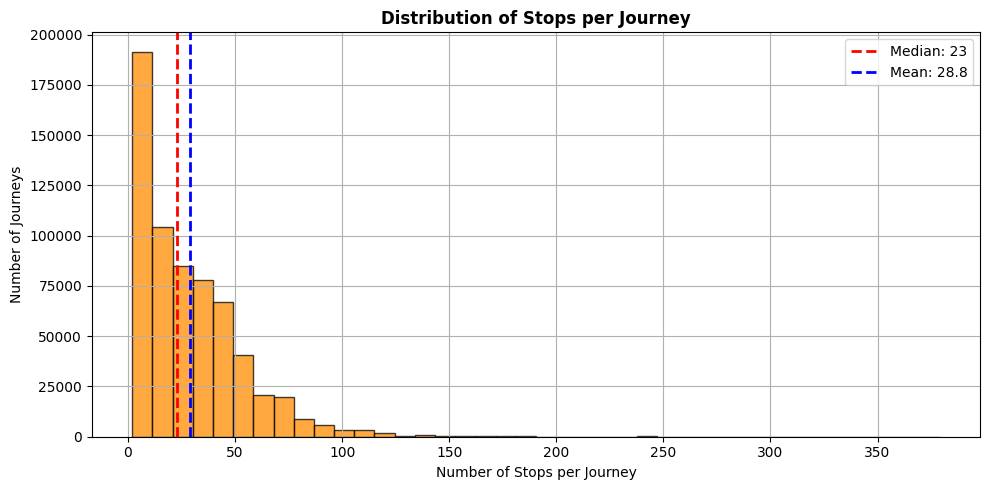

In [36]:
if "rid" in timetable_df.columns:
    stops_per_journey = timetable_df.groupby("rid").size()

    print("Stops per journey statistics:")
    print(stops_per_journey.describe().round(1))
    print()
    print(f"Journeys with 1 stop:      {(stops_per_journey == 1).sum():,}")
    print(f"Journeys with 2-5 stops:   {((stops_per_journey >= 2) & (stops_per_journey <= 5)).sum():,}")
    print(f"Journeys with 6-15 stops:  {((stops_per_journey >= 6) & (stops_per_journey <= 15)).sum():,}")
    print(f"Journeys with > 15 stops:  {(stops_per_journey > 15).sum():,}")

    plt.figure(figsize=(10, 5))
    stops_per_journey.hist(bins=40, edgecolor="black", alpha=0.75,
                           color="darkorange")
    plt.axvline(stops_per_journey.median(), color="red", linestyle="--",
                lw=2, label=f"Median: {stops_per_journey.median():.0f}")
    plt.axvline(stops_per_journey.mean(), color="blue", linestyle="--",
                lw=2, label=f"Mean: {stops_per_journey.mean():.1f}")
    plt.xlabel("Number of Stops per Journey")
    plt.ylabel("Number of Journeys")
    plt.title("Distribution of Stops per Journey", fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/eda_04/stops_per_journey.png", dpi=200, bbox_inches="tight")
    plt.show()

In [39]:
# TIPLOC codes link timetable stops to the stations reference
# Match rate determines how many scheduled stops can be spatially
# joined to nearby road closures in downstream notebooks

if "tpl" in timetable_df.columns and "tiploc" in stations_reference_df.columns:
    timetable_tpls = set(timetable_df["tpl"].dropna().str.strip().str.upper())
    reference_tpls = set(
        stations_reference_df["tiploc"].dropna().str.strip().str.upper()
    )
    matched   = timetable_tpls & reference_tpls
    unmatched = timetable_tpls - reference_tpls

    print(f"Unique TPLs in timetable:      {len(timetable_tpls):,}")
    print(f"TIPLOC codes in reference:     {len(reference_tpls):,}")
    print(f"Matched:                       {len(matched):,} ({len(matched)/len(timetable_tpls)*100:.1f}%)")
    print(f"Unmatched (timetable only):    {len(unmatched):,}")

    row_match = timetable_df["tpl"].str.strip().str.upper().isin(reference_tpls)
    print(f"\nStop rows with matched TIPLOC: {row_match.sum():,} ({row_match.mean()*100:.1f}%)")
    print(f"Stop rows without match:       {(~row_match).sum():,} ({(~row_match).mean()*100:.1f}%)")

    print(f"\nSample unmatched TIPLOCs (junctions, depots, waypoints):")
    print(sorted(unmatched)[:20])

Unique TPLs in timetable:      5,160
TIPLOC codes in reference:     2,594
Matched:                       2,583 (50.1%)
Unmatched (timetable only):    2,577

Stop rows with matched TIPLOC: 11,165,513 (61.3%)
Stop rows without match:       7,049,609 (38.7%)

Sample unmatched TIPLOCs (junctions, depots, waypoints):
['ABARASQ', 'ABCWM', 'ABDARAR', 'ABHLJN', 'ABINGTN', 'ABRBEG', 'ABRD222', 'ABRD223', 'ABRD229', 'ABRD230', 'ABRD27', 'ABRD55', 'ABRD56', 'ABRD77', 'ABRDCH', 'ABRDFGL', 'ABRDFJN', 'ABRDFTT', 'ABRGS38', 'ABTH']


In [40]:
# Mirror the delay feature derivation pattern from eda_03
# Here we derive scheduled-time features from the timetable
# rather than delay features from actual movements

# Parse working times to datetime where possible
# wta/wtd are HH:MM or HH:MM:SS strings relative to ssd (service date)
def parse_time_to_datetime(ssd, time_str):
    """Combine service date + time string into a UTC-aware datetime."""
    try:
        date_part = pd.to_datetime(ssd)
        time_parts = str(time_str).strip().split(":")
        hour = int(time_parts[0])
        minute = int(time_parts[1]) if len(time_parts) > 1 else 0
        second = int(time_parts[2]) if len(time_parts) > 2 else 0
        # Handle past-midnight services (hour >= 24)
        dt = date_part + pd.Timedelta(hours=hour, minutes=minute, seconds=second)
        return dt.tz_localize("UTC")
    except Exception:
        return pd.NaT

# Parse scheduled departure (wtd) and arrival (wta)
print("Parsing scheduled departure times...")
if "wtd" in timetable_df.columns and "ssd" in timetable_df.columns:
    timetable_df["scheduled_departure"] = timetable_df.apply(
        lambda r: parse_time_to_datetime(r["ssd"], r["wtd"])
        if pd.notna(r["wtd"]) else pd.NaT,
        axis=1
    )

if "wta" in timetable_df.columns and "ssd" in timetable_df.columns:
    timetable_df["scheduled_arrival"] = timetable_df.apply(
        lambda r: parse_time_to_datetime(r["ssd"], r["wta"])
        if pd.notna(r["wta"]) else pd.NaT,
        axis=1
    )

# Derive temporal features — consistent with eda_03 and eda_05_01
timetable_df["is_peak"] = timetable_df["sched_hour"].apply(
    lambda h: 1 if h is not None and (7 <= h <= 9 or 17 <= h <= 19) else 0
)
timetable_df["planned_date"] = pd.to_datetime(timetable_df["ssd"])
timetable_df["day_of_week"]  = pd.to_datetime(timetable_df["ssd"]).dt.dayofweek
timetable_df["is_weekend"]   = timetable_df["day_of_week"].isin([5, 6]).astype(int)
timetable_df["is_monday"]    = (timetable_df["day_of_week"] == 0).astype(int)
timetable_df["is_friday"]    = (timetable_df["day_of_week"] == 4).astype(int)

print(f"Scheduled departure parsed:  {timetable_df['scheduled_departure'].notna().sum():,} rows")
print(f"Scheduled arrival parsed:    {timetable_df['scheduled_arrival'].notna().sum():,} rows")
print(f"Peak hour stops:             {timetable_df['is_peak'].sum():,} ({timetable_df['is_peak'].mean()*100:.1f}%)")
print(f"Weekend stops:               {timetable_df['is_weekend'].sum():,} ({timetable_df['is_weekend'].mean()*100:.1f}%)")

Parsing scheduled departure times...
Scheduled departure parsed:  9,726,830 rows
Scheduled arrival parsed:    9,726,897 rows
Peak hour stops:             3,352,818 (18.4%)
Weekend stops:               4,006,658 (22.0%)


In [41]:
# All stop types retained — consistent with user requirement
# Downstream notebooks (eda_06_01) can filter further as needed

clean_df = timetable_df.copy()

clean_df.to_parquet(
    "./data/processed/darwin_timetable_clean.parquet", index=False
)

print(f"Saved: darwin_timetable_clean.parquet — {len(clean_df):,} rows")
print(f"Unique journeys:  {clean_df['rid'].nunique():,}")
print(f"Unique stations:  {clean_df['tpl'].nunique():,}")
print(f"Date range:       {clean_df['planned_date'].min()} to {clean_df['planned_date'].max()}")
print()
clean_df.info()

Saved: darwin_timetable_clean.parquet — 18,215,122 rows
Unique journeys:  633,103
Unique stations:  5,160
Date range:       2026-04-09 00:00:00 to 2026-04-30 00:00:00

<class 'pandas.DataFrame'>
Index: 18215122 entries, 0 to 18215989
Data columns (total 23 columns):
 #   Column               Dtype              
---  ------               -----              
 0   rid                  str                
 1   uid                  str                
 2   trainId              str                
 3   ssd                  object             
 4   toc                  str                
 5   stop_type            str                
 6   tpl                  str                
 7   platform             str                
 8   act                  str                
 9   pta                  str                
 10  ptd                  str                
 11  wta                  str                
 12  wtd                  str                
 13  wtp                  str              